<a href="https://colab.research.google.com/github/abuzar01440/abuzar-portfolio/blob/main/Quantium_task_2_remote_intership.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, ttest_ind
import os

In [3]:
df = pd.read_csv("/content/QVI_data.csv")
df.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [5]:
print("The shape of a df",df.shape)

The shape of a df (264834, 12)


In [7]:
df.isnull().sum() #check null values

,0
LYLTY_CARD_NBR,0
DATE,0
STORE_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0
PACK_SIZE,0
BRAND,0


In [8]:
df.duplicated().sum() #check duplicated values

np.int64(1)

In [9]:
print("Before removing duplicate", df.shape)
df.drop_duplicates(inplace=True)
print("After removing duplicate", df.shape)

Before removing duplicate (264834, 12)
After removing duplicate (264833, 12)


In [10]:
df.describe()

,LYLTY_CARD_NBR,STORE_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES,PACK_SIZE
count,2.648330e+05,264833.000000,2.648330e+05,264833.000000,264833.000000,264833.000000,264833.000000
mean,1.355489e+05,135.079529,1.351577e+05,56.583598,1.905812,7.299351,182.425540
std,8.058003e+04,76.784189,7.813305e+04,32.826498,0.343437,2.527244,64.325268
min,1.000000e+03,1.000000,1.000000e+00,1.000000,1.000000,1.500000,70.000000
25%,7.002100e+04,70.000000,6.760000e+04,28.000000,2.000000,5.400000,150.000000
50%,1.303570e+05,130.000000,1.351370e+05,56.000000,2.000000,7.400000,170.000000
75%,2.030940e+05,203.000000,2.027000e+05,85.000000,2.000000,9.200000,175.000000
max,2.373711e+06,272.000000,2.415841e+06,114.000000,5.000000,29.500000,380.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 264833 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264833 non-null  int64  
 1   DATE              264833 non-null  object 
 2   STORE_NBR         264833 non-null  int64  
 3   TXN_ID            264833 non-null  int64  
 4   PROD_NBR          264833 non-null  int64  
 5   PROD_NAME         264833 non-null  object 
 6   PROD_QTY          264833 non-null  int64  
 7   TOT_SALES         264833 non-null  float64
 8   PACK_SIZE         264833 non-null  int64  
 9   BRAND             264833 non-null  object 
 10  LIFESTAGE         264833 non-null  object 
 11  PREMIUM_CUSTOMER  264833 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 26.3+ MB


In [12]:
# Convert DATE to datetime
df['DATE'] = pd.to_datetime(df['DATE'])

# Create YearMonth column
df['YEAR_MONTH'] = df['DATE'].dt.to_period('M')

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 264833 entries, 0 to 264833
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   LYLTY_CARD_NBR    264833 non-null  int64         
 1   DATE              264833 non-null  datetime64[ns]
 2   STORE_NBR         264833 non-null  int64         
 3   TXN_ID            264833 non-null  int64         
 4   PROD_NBR          264833 non-null  int64         
 5   PROD_NAME         264833 non-null  object        
 6   PROD_QTY          264833 non-null  int64         
 7   TOT_SALES         264833 non-null  float64       
 8   PACK_SIZE         264833 non-null  int64         
 9   BRAND             264833 non-null  object        
 10  LIFESTAGE         264833 non-null  object        
 11  PREMIUM_CUSTOMER  264833 non-null  object        
 12  YEAR_MONTH        264833 non-null  period[M]     
dtypes: datetime64[ns](1), float64(1), int64(6), object(4), period[M]

In [13]:
df.YEAR_MONTH

,YEAR_MONTH
0,2018-10
1,2018-09
2,2019-03
3,2019-03
4,2018-11
...,...
264829,2018-12
264830,2018-10
264831,2018-10
264832,2018-10


In [14]:
# Group by store and month
monthly_metrics = df.groupby(['STORE_NBR', 'YEAR_MONTH']).agg(
    monthly_sales=('TOT_SALES', 'sum'),
    monthly_customers=('LYLTY_CARD_NBR', 'nunique'),
    monthly_transactions=('TXN_ID', 'nunique')
).reset_index()

In [15]:
monthly_metrics

,STORE_NBR,YEAR_MONTH,monthly_sales,monthly_customers,monthly_transactions
0,1,2018-07,206.9,49,52
1,1,2018-08,176.1,42,43
2,1,2018-09,278.8,59,62
3,1,2018-10,188.1,44,45
4,1,2018-11,192.6,46,47
...,...,...,...,...,...
3164,272,2019-02,395.5,45,48
3165,272,2019-03,442.3,50,53
3166,272,2019-04,445.1,54,55
3167,272,2019-05,314.6,34,40


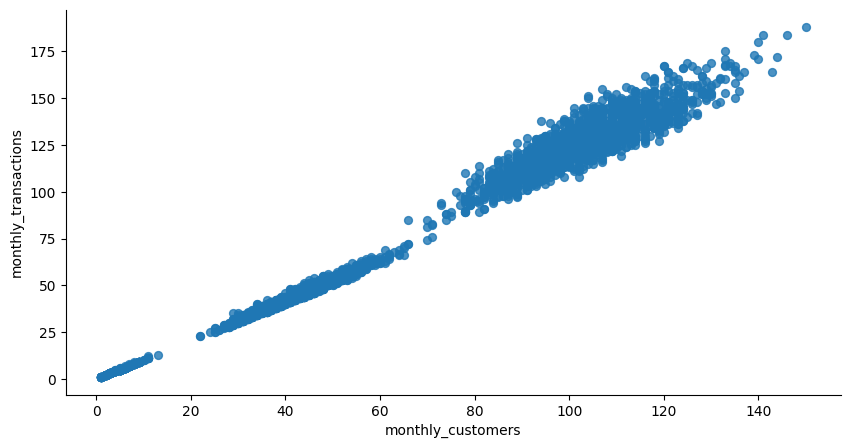

In [31]:
# @title monthly_customers vs monthly_transactions
monthly_metrics.plot(kind='scatter', x='monthly_customers', y='monthly_transactions', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

In [17]:
np.unique(df.STORE_NBR)

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

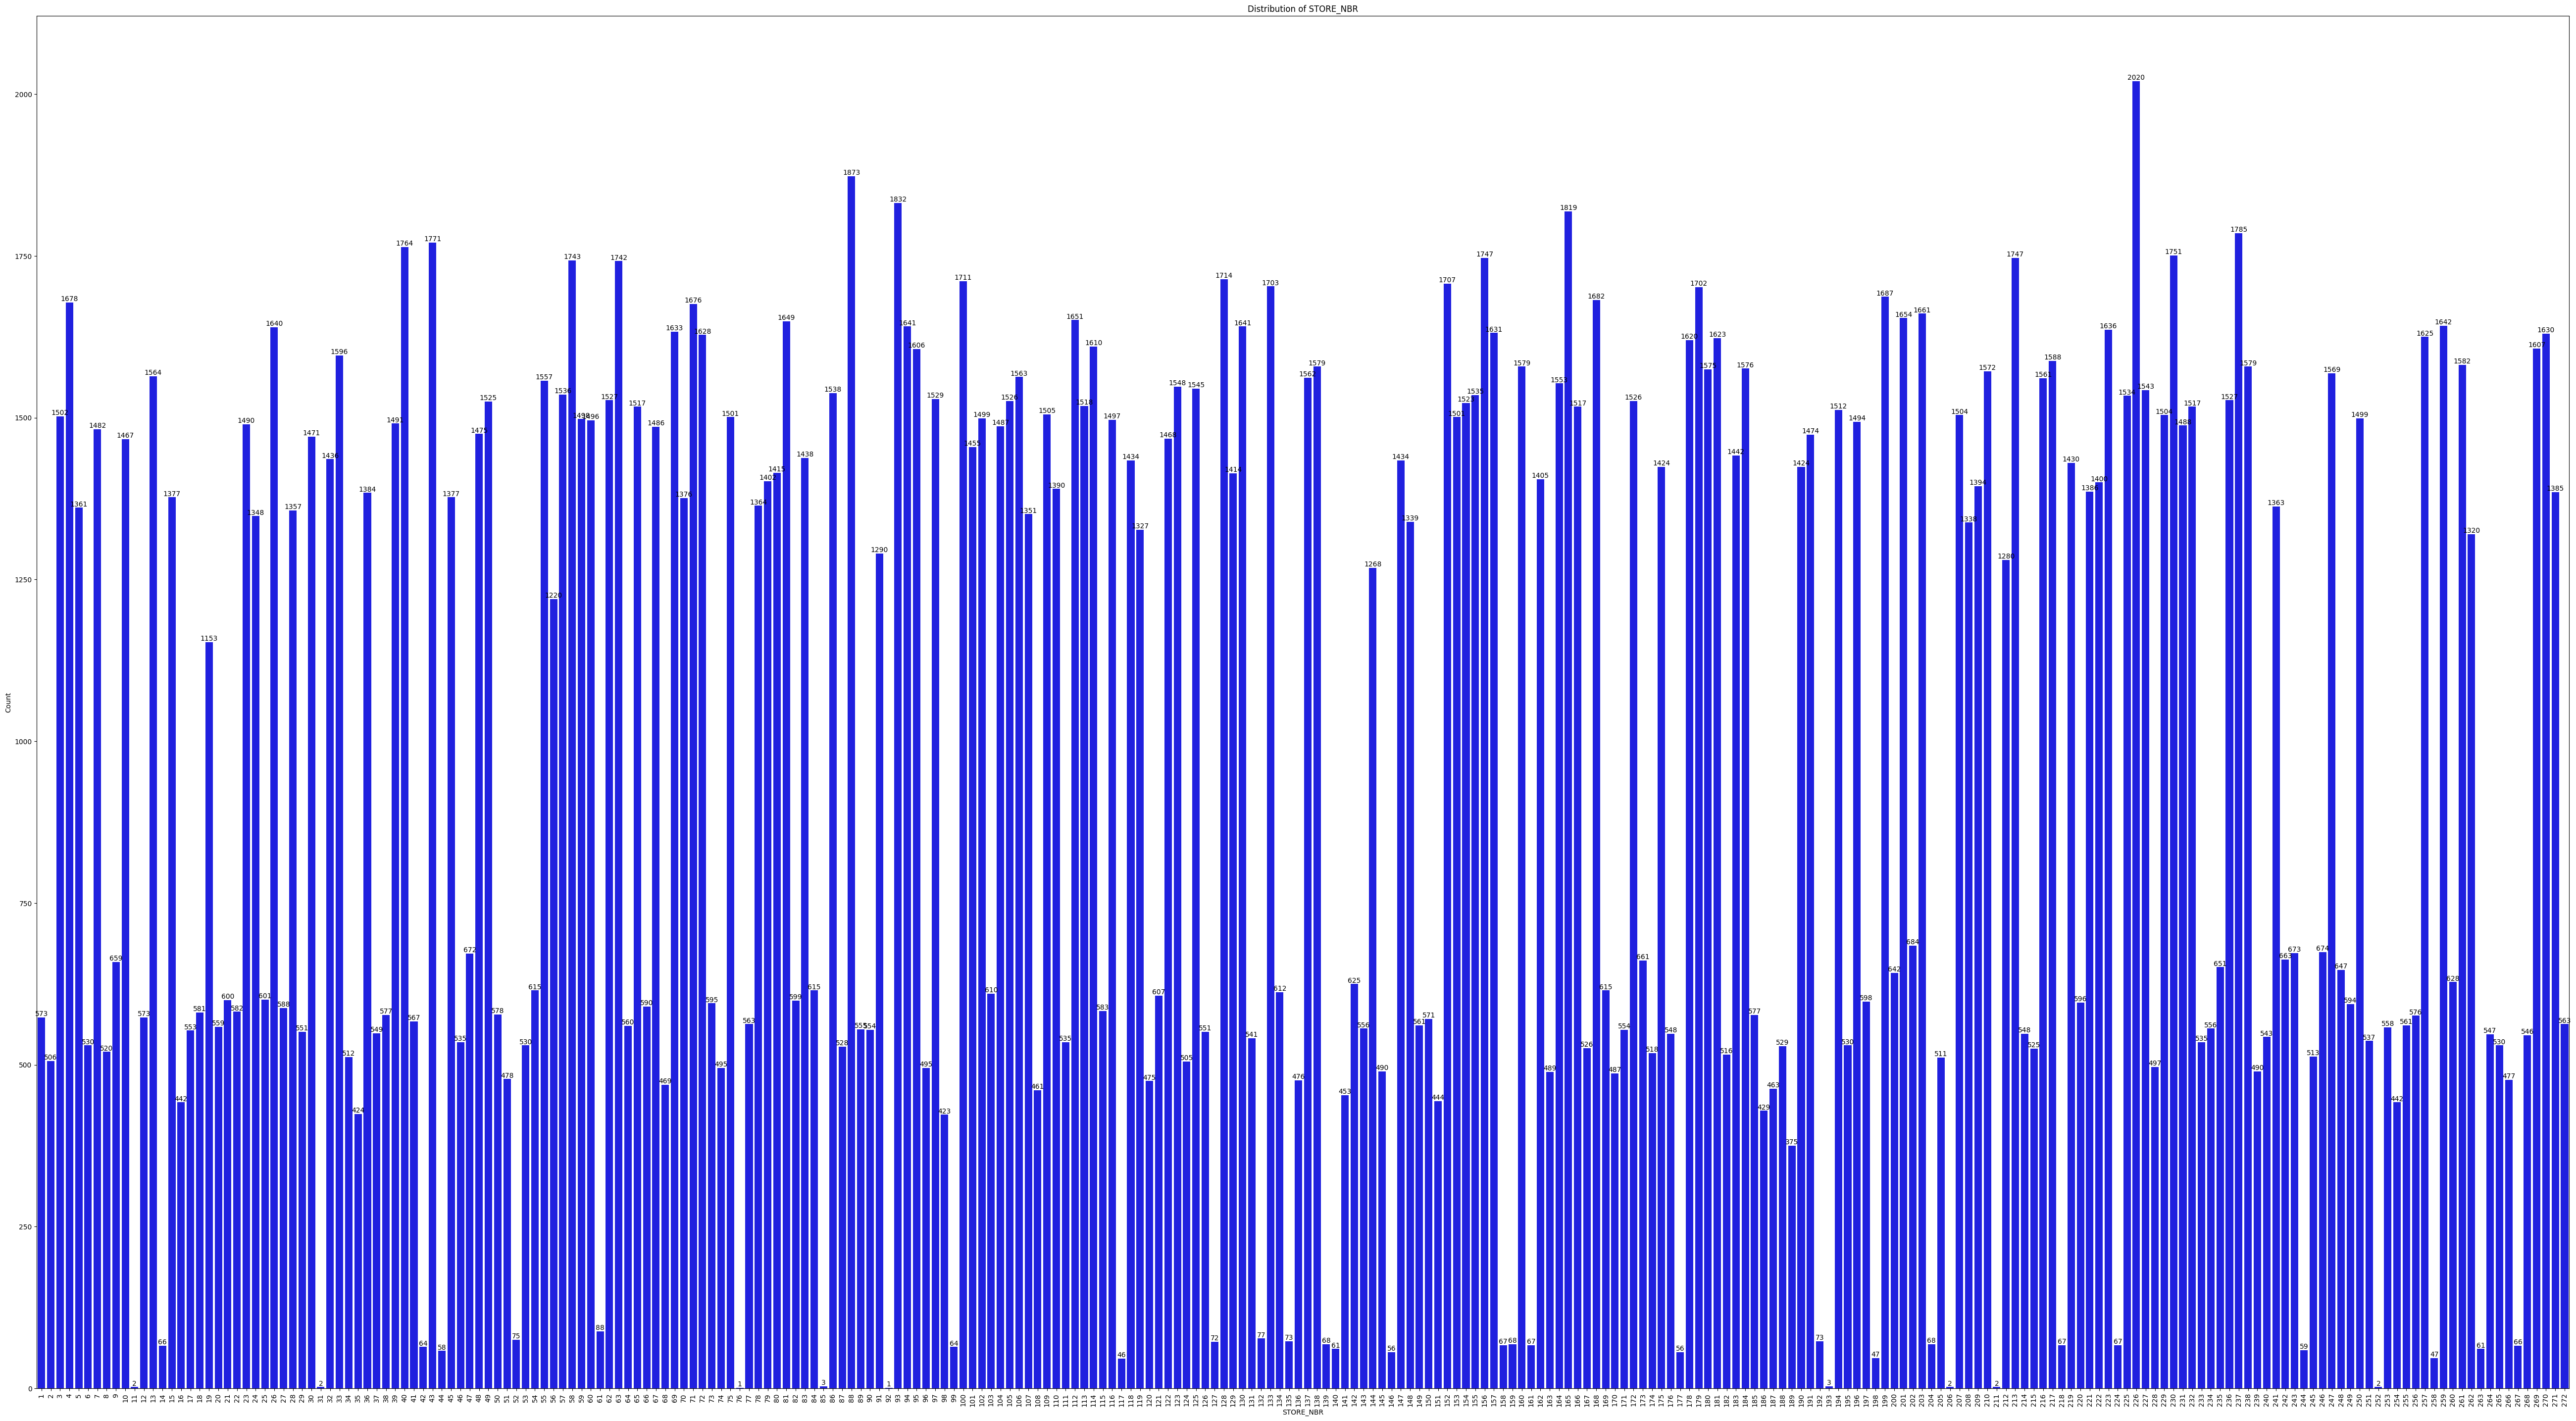

In [24]:
#fig size
plt.figure(figsize=(66,36))
sns.countplot(data=df, x='STORE_NBR', color='blue')
# annotate
plt.bar_label(plt.gca().containers[0])
plt.xticks(rotation=90)
plt.xlabel('STORE_NBR')
plt.ylabel('Count')
plt.title('Distribution of STORE_NBR')
plt.show()

In [16]:
# MAX and mini monthly sales w.r.t STORE_NBR at what date

max_monthly_sales = monthly_metrics.groupby('STORE_NBR')['monthly_sales'].idxmax()
min_monthly_sales = monthly_metrics.groupby('STORE_NBR')['monthly_sales'].idxmin()

print("Maximum Monthly Sales:")
print("max_monthly_sales", max_monthly_sales)
print("Minimum Monthly Sales:")
print("min_monthly_sales", min_monthly_sales)
print(monthly_metrics.loc[max_monthly_sales, ['STORE_NBR', 'YEAR_MONTH', 'monthly_sales']])
print(monthly_metrics.loc[min_monthly_sales,['STORE_NBR', 'YEAR_MONTH', 'monthly_sales']])

Maximum Monthly Sales:
max_monthly_sales STORE_NBR
1         2
2        21
3        24
4        42
5        59
       ... 
268    3110
269    3124
270    3139
271    3145
272    3166
Name: monthly_sales, Length: 272, dtype: int64
Minimum Monthly Sales:
min_monthly_sales STORE_NBR
1         6
2        17
3        33
4        43
5        56
       ... 
268    3115
269    3122
270    3136
271    3146
272    3159
Name: monthly_sales, Length: 272, dtype: int64
      STORE_NBR YEAR_MONTH  monthly_sales
2             1    2018-09         278.80
21            2    2019-04         196.50
24            3    2018-07        1205.70
42            4    2019-01        1525.00
59            5    2019-06         910.80
...         ...        ...            ...
3110        268    2018-08         322.65
3124        269    2018-10        1078.40
3139        270    2019-01        1066.60
3145        271    2018-07         956.60
3166        272    2019-04         445.10

[272 rows x 3 columns]
      STORE_

In [25]:
monthly_metrics.loc[min_monthly_sales,['STORE_NBR', 'YEAR_MONTH', 'monthly_sales']]

,STORE_NBR,YEAR_MONTH,monthly_sales
6,1,2019-01,154.8
17,2,2018-12,136.0
33,3,2019-04,920.0
43,4,2019-02,883.4
56,5,2019-03,681.4
...,...,...,...
3115,268,2019-01,157.7
3122,269,2018-08,835.1
3136,270,2018-10,816.4
3146,271,2018-08,683.9


from matplotlib import pyplot as plt
_df_0['STORE_NBR'].plot(kind='hist', bins=20, title='STORE_NBR')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['monthly_sales'].plot(kind='hist', bins=20, title='monthly_sales')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2.plot(kind='scatter', x='STORE_NBR', y='monthly_sales', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['STORE_NBR']
  ys = series['monthly_sales']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_3.sort_values('STORE_NBR', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('STORE_NBR')
_ = plt.ylabel('monthly_sales')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['STORE_NBR']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'STORE_NBR'}, axis=1)
              .sort_values('STORE_NBR', ascending=True))
  xs = counted['STORE_NBR']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_4.sort_values('STORE_NBR', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('STORE_NBR')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_5['STORE_NBR'].plot(kind='line', figsize=(8, 4), title='STORE_NBR')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_6['monthly_sales'].plot(kind='line', figsize=(8, 4), title='monthly_sales')
plt.gca().spines[['top', 'right']].set_visible(False)

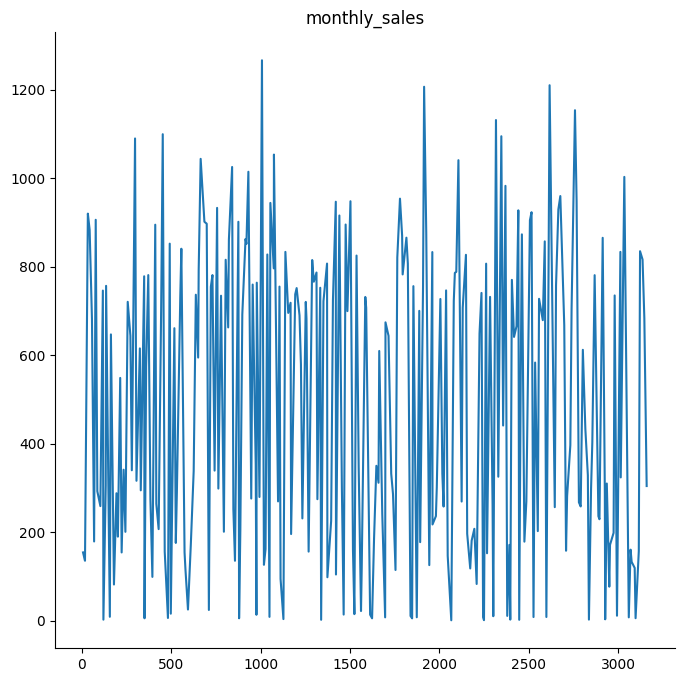

In [26]:
from matplotlib import pyplot as plt
_df_6['monthly_sales'].plot(kind='line', figsize=(8, 8), title='monthly_sales')
plt.gca().spines[['top', 'right']].set_visible(False)

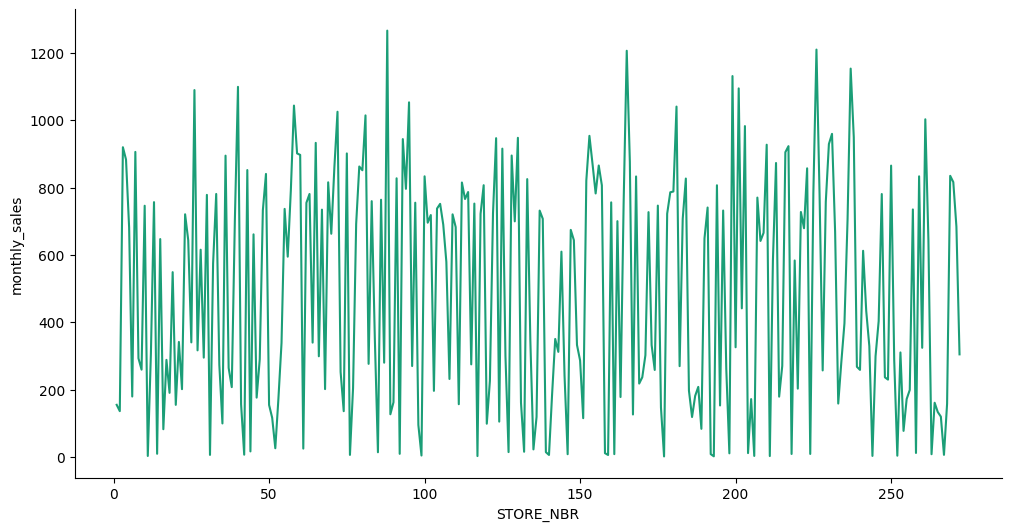

In [27]:

def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['STORE_NBR']
  ys = series['monthly_sales']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_3.sort_values('STORE_NBR', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('STORE_NBR')
_ = plt.ylabel('monthly_sales')

In [33]:
# Calculate average transactions per customer
monthly_metrics['avg_transactions_per_customer'] = (monthly_metrics['monthly_transactions'] / monthly_metrics['monthly_customers'])


monthly_metrics.avg_transactions_per_customer


,avg_transactions_per_customer
0,1.061224
1,1.023810
2,1.050847
3,1.022727
4,1.021739
...,...
3164,1.066667
3165,1.060000
3166,1.018519
3167,1.176471


In [36]:
monthly_metrics.avg_transactions_per_customer.describe() # stats avg_transactions_per_customer

,avg_transactions_per_customer
count,3169.000000
mean,1.141307
std,0.111341
min,1.000000
25%,1.041667
50%,1.125000
75%,1.233645
max,1.468085


In [37]:
all_months = pd.period_range(start=df['YEAR_MONTH'].min(), end=df['YEAR_MONTH'].max(), freq='M')
all_stores = df['STORE_NBR'].unique()

In [42]:
print('Total number',len(all_months))
print('Total number',len(all_stores))

print("ALL Months details",all_months)
print("ALL Stores details",all_stores)

Total number 12
Total number 272
ALL Months details PeriodIndex(['2018-07', '2018-08', '2018-09', '2018-10', '2018-11', '2018-12',
             '2019-01', '2019-02', '2019-03', '2019-04', '2019-05', '2019-06'],
            dtype='period[M]')
ALL Stores details [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86 155  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 

In [45]:
multi_index = pd.MultiIndex.from_product([all_stores, all_months], names=['STORE_NBR', 'YEAR_MONTH'])

# Reindex the monthly_metrics DataFrame
monthly_metrics_full = monthly_metrics.set_index(['STORE_NBR', 'YEAR_MONTH']).reindex(multi_index).reset_index()


In [48]:
df.YEAR_MONTH.min()

Period('2018-07', 'M')

In [49]:
df.YEAR_MONTH.max()

Period('2019-06', 'M')

In [50]:
TRIAL_STORES = [77, 86, 88]
PRE_TRIAL_START_MONTH = pd.Period('2018-06', freq='M')
PRE_TRIAL_END_MONTH = pd.Period('2019-01', freq='M')
TRIAL_START_MONTH = pd.Period('2019-02', freq='M')
TRIAL_END_MONTH = pd.Period('2019-04', freq='M')

In [51]:
pre_trial_metrics = monthly_metrics_full[
    (monthly_metrics_full['YEAR_MONTH'] >= PRE_TRIAL_START_MONTH) &
    (monthly_metrics_full['YEAR_MONTH'] <= PRE_TRIAL_END_MONTH)]

# Separate trial and non-trial stores for control selection
pre_trial_trial_stores = pre_trial_metrics[pre_trial_metrics['STORE_NBR'].isin(TRIAL_STORES)]
pre_trial_control_candidates = pre_trial_metrics[~pre_trial_metrics['STORE_NBR'].isin(TRIAL_STORES)]


In [52]:
pre_trial_trial_stores

,STORE_NBR,YEAR_MONTH,monthly_sales,monthly_customers,monthly_transactions,avg_transactions_per_customer
912,77,2018-07,296.80,51.0,55.0,1.078431
913,77,2018-08,255.50,47.0,48.0,1.021277
914,77,2018-09,225.20,42.0,44.0,1.047619
915,77,2018-10,204.50,37.0,38.0,1.027027
916,77,2018-11,245.30,41.0,44.0,1.073171
917,77,2018-12,267.30,46.0,48.0,1.043478
918,77,2019-01,204.40,35.0,39.0,1.114286
1020,86,2018-07,892.20,99.0,126.0,1.272727
1021,86,2018-08,764.05,94.0,110.0,1.170213
1022,86,2018-09,914.60,103.0,128.0,1.242718


In [53]:
pre_trial_control_candidates

,STORE_NBR,YEAR_MONTH,monthly_sales,monthly_customers,monthly_transactions,avg_transactions_per_customer
0,1,2018-07,206.9,49.0,52.0,1.061224
1,1,2018-08,176.1,42.0,43.0,1.023810
2,1,2018-09,278.8,59.0,62.0,1.050847
3,1,2018-10,188.1,44.0,45.0,1.022727
4,1,2018-11,192.6,46.0,47.0,1.021739
...,...,...,...,...,...,...
3254,272,2018-09,304.7,32.0,36.0,1.125000
3255,272,2018-10,430.6,44.0,50.0,1.136364
3256,272,2018-11,376.2,41.0,45.0,1.097561
3257,272,2018-12,403.9,47.0,47.0,1.000000


In [59]:
OUTPUT_VIS_DIR = '/content/viz' # Directory to save plots

In [60]:
def calculate_correlation(series1, series2):
    """Calculates Pearson correlation between two pandas Series."""
    # Ensure series are aligned and have same length (already handled by reindexing)
    corr, _ = pearsonr(series1, series2)
    return corr

def calculate_magnitude_distance(series1, series2):
    """Calculates Euclidean distance between two pandas Series."""
    return np.sqrt(np.sum((series1 - series2)**2))

def scale_distance(distance, min_dist, max_dist):
    """Scales distance using the provided formula."""
    if max_dist == min_dist: # Avoid division by zero
        return 0.0 # If all distances are the same, scale to 0 or 1 depending on preference
    return 1 - (distance - min_dist) / (max_dist - min_dist) # Higher score is better

def find_control_store(trial_store_id, trial_metrics, control_candidate_metrics, metric_to_correlate='monthly_sales'):
    """
    Finds the best control store for a given trial store based on pre-trial metric correlation.

    Args:
        trial_store_id (int): The ID of the trial store.
        trial_metrics (pd.DataFrame): Pre-trial metrics for the trial store (indexed by YEAR_MONTH).
        control_candidate_metrics (pd.DataFrame): Pre-trial metrics for all potential control stores.
        metric_to_correlate (str): The metric column name to use for correlation ('monthly_sales' or 'monthly_customers').

    Returns:
        tuple: (best_control_store_id, dictionary of correlations/distances) or (None, {}) if no candidates.
    """
    trial_series = trial_metrics[metric_to_correlate]
    correlations = {}
    distances = {}

    candidate_stores = control_candidate_metrics['STORE_NBR'].unique()

    if not len(candidate_stores):
        return None, {}

    for store_id in candidate_stores:
        control_series = control_candidate_metrics[control_candidate_metrics['STORE_NBR'] == store_id].set_index('YEAR_MONTH')[metric_to_correlate]
        # Ensure the control series has the same index as the trial series
        control_series = control_series.reindex(trial_series.index).fillna(0)

        # Check for zero variance (which makes correlation undefined or zero)
        if trial_series.std() == 0 or control_series.std() == 0:
            correlations[store_id] = 0 # Assign 0 correlation if one series is flat
        else:
            correlations[store_id] = calculate_correlation(trial_series, control_series)

        distances[store_id] = calculate_magnitude_distance(trial_series, control_series)

    # --- Option 1: Select based on highest correlation ---
    best_control_store_corr = max(correlations, key=correlations.get) if correlations else None

    # --- Option 2: Select based on lowest distance (or highest scaled distance) ---
    if distances:
        min_dist = min(distances.values())
        max_dist = max(distances.values())
        scaled_distances = {store: scale_distance(dist, min_dist, max_dist) for store, dist in distances.items()}
        best_control_store_dist = max(scaled_distances, key=scaled_distances.get)
    else:
        best_control_store_dist = None
        scaled_distances = {}

    # --- Simple Approach: Return best based on correlation for now ---
    # More sophisticated: combine scores or prioritize based on visual check
    print(f"Finding control for Trial Store {trial_store_id} using {metric_to_correlate}:")
    print(f"  Correlations: {correlations}")
    print(f"  Distances: {distances}")
    print(f"  Scaled Distances: {scaled_distances}")


    # Return best correlation-based control and the scores for visualization/logging
    return best_control_store_corr, {'correlations': correlations, 'distances': distances, 'scaled_distances': scaled_distances}

def plot_control_candidates(trial_store_id, trial_metrics, control_candidate_metrics, scores_dict, metric, num_candidates=5):
    """Plots trial store vs top control candidates for visual inspection."""
    trial_ts = trial_metrics.set_index('YEAR_MONTH')[metric]

    # Sort candidates by correlation (descending) or scaled distance (descending)
    # Using correlation here
    sorted_candidates = sorted(scores_dict['correlations'].items(), key=lambda item: item[1], reverse=True)
    # Or using scaled distance:
    # sorted_candidates = sorted(scores_dict['scaled_distances'].items(), key=lambda item: item[1], reverse=True)


    top_candidate_ids = [store_id for store_id, score in sorted_candidates[:num_candidates]]

    plt.figure(figsize=(12, 6))
    plt.plot(trial_ts.index.to_timestamp(), trial_ts.values, label=f'Trial Store {trial_store_id}', linewidth=2)

    for store_id in top_candidate_ids:
        control_ts = control_candidate_metrics[control_candidate_metrics['STORE_NBR'] == store_id].set_index('YEAR_MONTH')[metric]
        control_ts = control_ts.reindex(trial_ts.index).fillna(0) # Align index
        corr = scores_dict['correlations'].get(store_id, 'N/A')
        dist_score = scores_dict['scaled_distances'].get(store_id, 'N/A')
        plt.plot(control_ts.index.to_timestamp(), control_ts.values, label=f'Control Cand. {store_id} (Corr: {corr:.2f}, DistSc: {dist_score:.2f})', linestyle='--')

    plt.title(f'Pre-Trial {metric.replace("_", " ").title()} Comparison: Trial Store {trial_store_id} vs Candidates')
    plt.xlabel('Month')
    plt.ylabel(metric.replace("_", " ").title())
    plt.legend()
    plt.grid(True, axis='y', linestyle=':')
    plt.tight_layout()
    # Save the plot
    filename = os.path.join(OUTPUT_VIS_DIR, f'control_selection_store_{trial_store_id}_{metric}.png')
    plt.savefig(filename)
    print(f"Saved control selection plot: {filename}")
    # plt.show() # Optional: display plot immediately
    plt.close()


# --- Main Control Selection Loop ---
print("\nSelecting Control Stores...")
control_store_map = {} # Dictionary to store {trial_store: control_store}

for trial_store in TRIAL_STORES:
    print(f"\nProcessing Trial Store: {trial_store}")
    trial_store_pre_trial_metrics = pre_trial_trial_stores[pre_trial_trial_stores['STORE_NBR'] == trial_store]

    if trial_store_pre_trial_metrics.empty:
        print(f"  Warning: No pre-trial data found for trial store {trial_store}. Skipping.")
        continue

    # Find control based on SALES correlation first
    best_control_sales, sales_scores = find_control_store(
        trial_store,
        trial_store_pre_trial_metrics.set_index('YEAR_MONTH'),
        pre_trial_control_candidates,
        metric_to_correlate='monthly_sales'
    )

    # Find control based on CUSTOMER correlation
    best_control_cust, cust_scores = find_control_store(
        trial_store,
        trial_store_pre_trial_metrics.set_index('YEAR_MONTH'),
        pre_trial_control_candidates,
        metric_to_correlate='monthly_customers'
    )

    # --- Decision Logic (Example: Prioritize sales correlation, but requires visual check) ---
    # For now, we'll just use the one based on sales, but plotting both helps decide.
    # In a real scenario, you'd review the plots and potentially choose differently.
    chosen_control = best_control_sales
    control_store_map[trial_store] = chosen_control

    print(f"  Selected Control Store for {trial_store}: {chosen_control} (Based on Sales Correlation)")
    # print(f"  (Customer Correlation suggests: {best_control_cust})")


    # --- Visualize Candidates ---
    if not trial_store_pre_trial_metrics.empty:
        # Plot based on Sales
        plot_control_candidates(
            trial_store,
            trial_store_pre_trial_metrics,
            pre_trial_control_candidates,
            sales_scores,
            'monthly_sales'
        )
        # Plot based on Customers
        plot_control_candidates(
            trial_store,
            trial_store_pre_trial_metrics,
            pre_trial_control_candidates,
            cust_scores,
            'monthly_customers'
        )

print("\nControl Store Selection Complete:")
print(control_store_map)


Selecting Control Stores...

Processing Trial Store: 77
Finding control for Trial Store 77 using monthly_sales:
  Correlations: {np.int64(1): np.float64(0.07521784241886476), np.int64(2): np.float64(-0.26307873083199074), np.int64(3): np.float64(0.8066436365226516), np.int64(4): np.float64(-0.2632996004856205), np.int64(5): np.float64(-0.11065230624397057), np.int64(6): np.float64(0.042489749681693556), np.int64(7): np.float64(-0.193885947368476), np.int64(8): np.float64(-0.3073603732839488), np.int64(9): np.float64(-0.7029760485789349), np.int64(10): np.float64(-0.04000838705252316), np.int64(11): np.float64(-0.05152375171989779), np.int64(12): np.float64(0.04630520307322565), np.int64(13): np.float64(-0.25336218374686226), np.int64(14): np.float64(0.43559352330876444), np.int64(15): np.float64(-0.25461792319578547), np.int64(16): np.float64(-0.21425544542670208), np.int64(17): np.float64(0.8426683602788767), np.int64(18): np.float64(0.03322767250372105), np.int64(19): np.float64(-0.

In [62]:
from IPython.display import Image, display

control_selection_store_88_monthly_customers.png


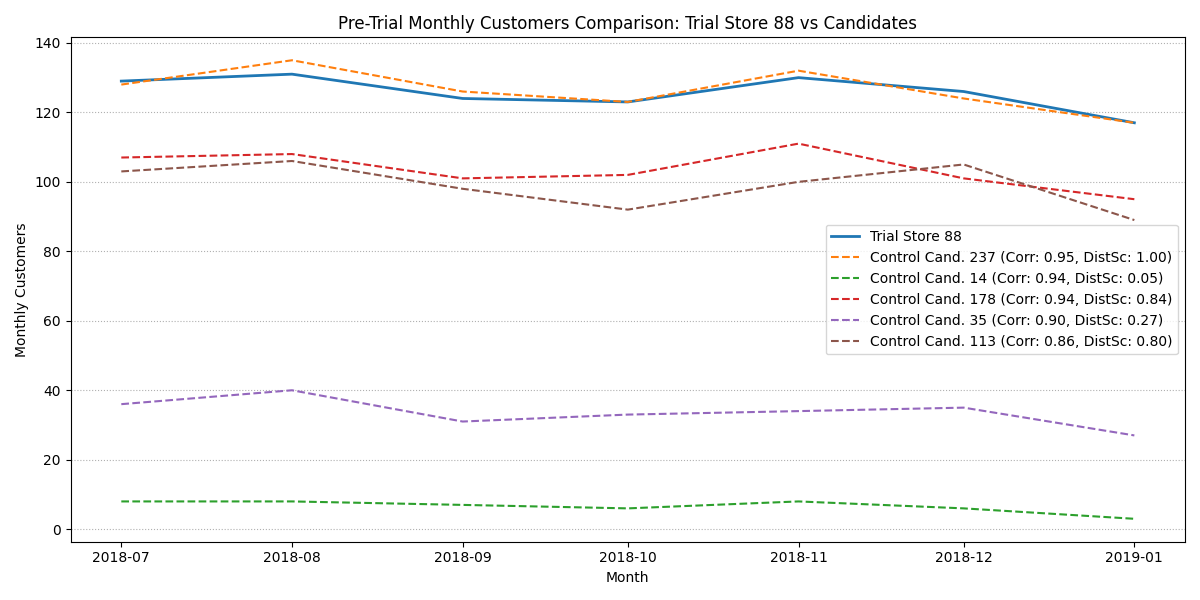

control_selection_store_86_monthly_sales.png


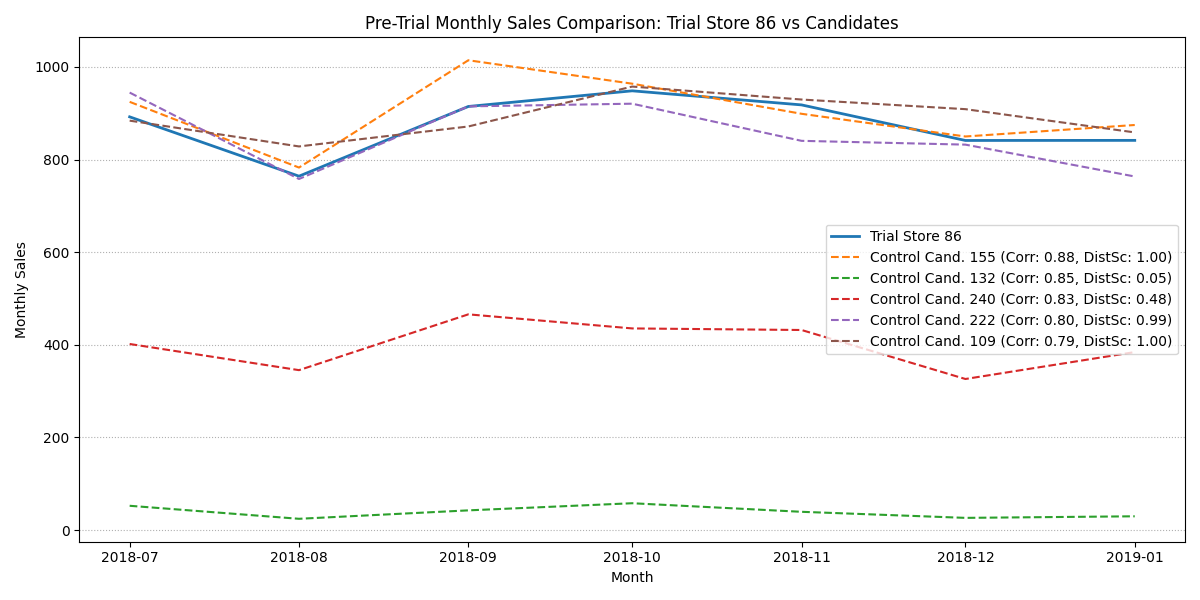

control_selection_store_77_monthly_customers.png


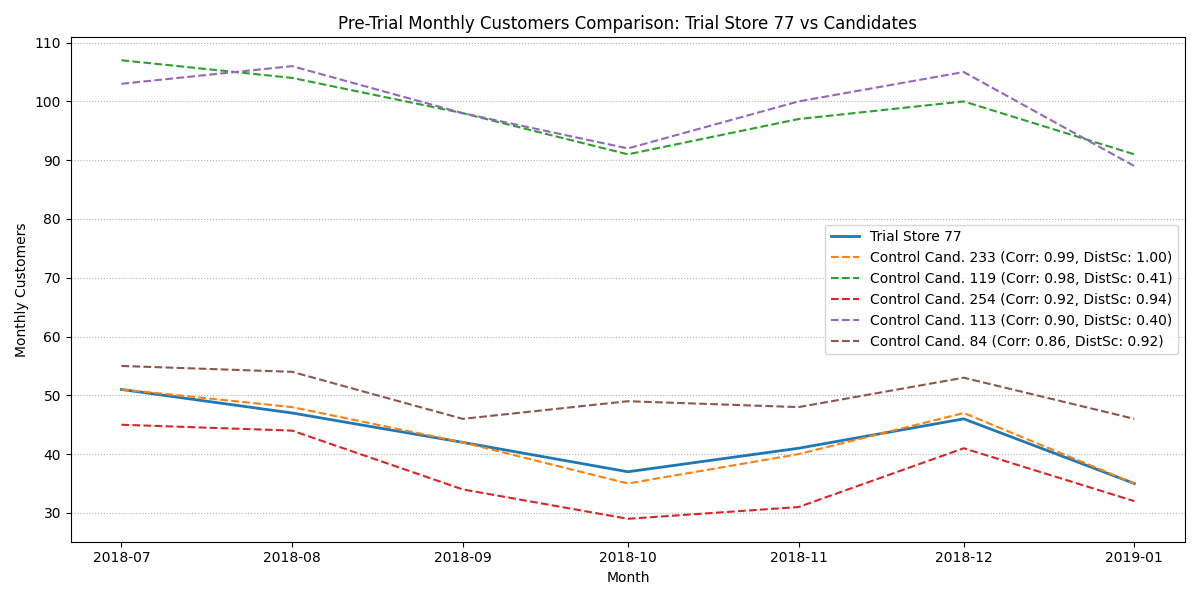

control_selection_store_86_monthly_customers.png


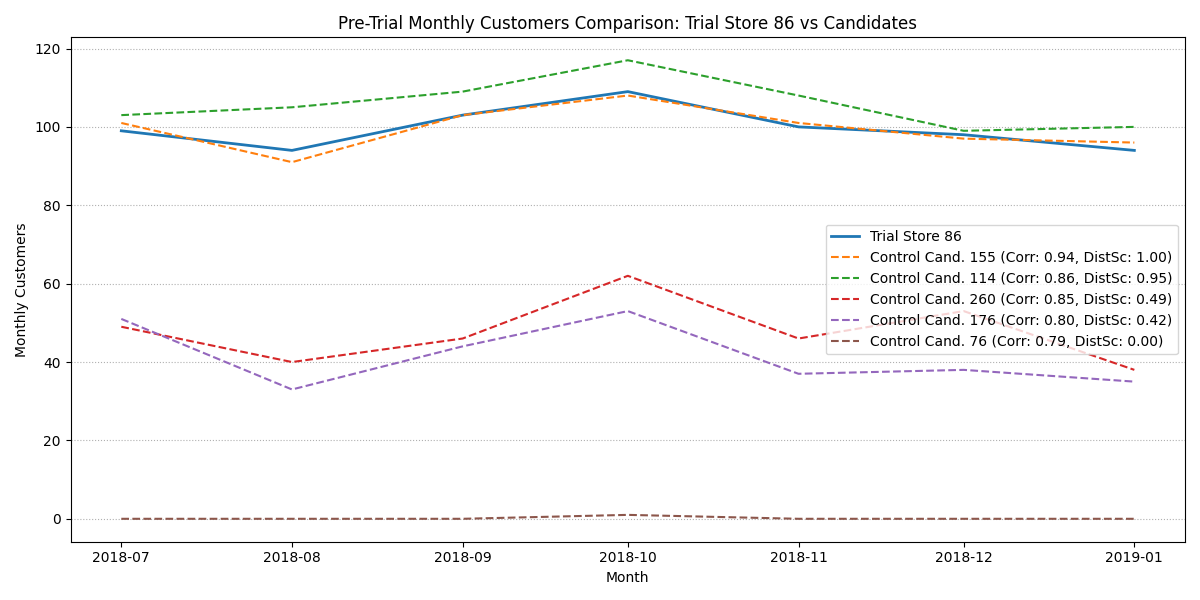

control_selection_store_88_monthly_sales.png


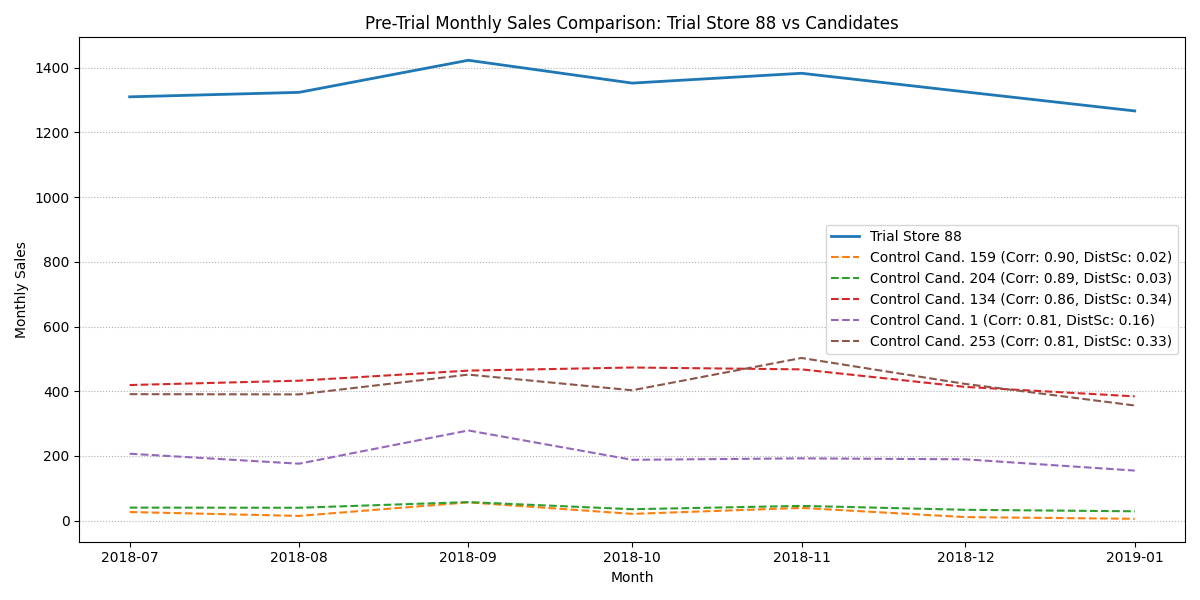

control_selection_store_77_monthly_sales.png


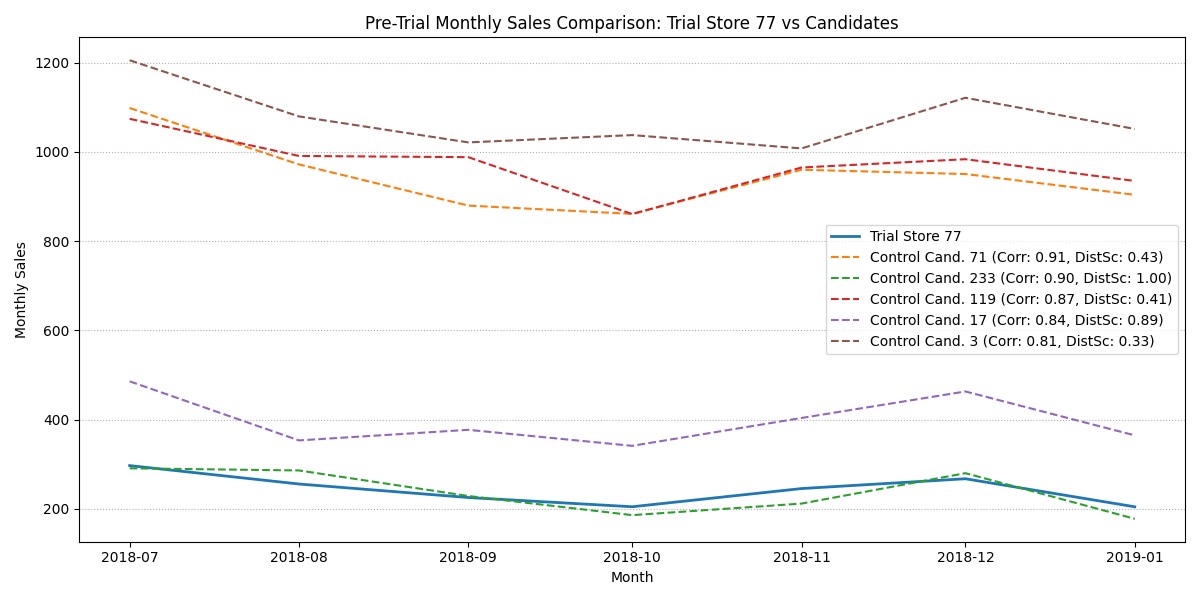

In [63]:
#plot the images of viz dir
for img in os.listdir(OUTPUT_VIS_DIR):
    print(img)
    display(Image(os.path.join(OUTPUT_VIS_DIR, img)))

In [64]:
print("\nAssessing Trial Performance...")
assessment_results = {}

# Get metrics for the full period for plotting and analysis
full_period_metrics = monthly_metrics_full[
    (monthly_metrics_full['YEAR_MONTH'] >= PRE_TRIAL_START_MONTH) &
    (monthly_metrics_full['YEAR_MONTH'] <= TRIAL_END_MONTH)
]

for trial_store, control_store in control_store_map.items():
    print(f"\n--- Assessing Trial Store {trial_store} (Control: {control_store}) ---")

    if control_store is None:
        print("  No control store selected. Skipping assessment.")
        assessment_results[trial_store] = {'Recommendation': 'Cannot assess - no control store found.', 'Significance (Sales)': 'N/A'}
        continue

    # Get pre-trial data for scaling factors
    pre_trial_trial = pre_trial_metrics[pre_trial_metrics['STORE_NBR'] == trial_store]
    pre_trial_control = pre_trial_metrics[pre_trial_metrics['STORE_NBR'] == control_store]

    # Calculate total pre-trial metrics for scaling factors
    # Handle potential division by zero if pre-trial totals are zero
    pre_trial_trial_sales_total = pre_trial_trial['monthly_sales'].sum()
    pre_trial_control_sales_total = pre_trial_control['monthly_sales'].sum()
    pre_trial_trial_cust_total = pre_trial_trial['monthly_customers'].sum()
    pre_trial_control_cust_total = pre_trial_control['monthly_customers'].sum()

    scaling_factor_sales = (pre_trial_trial_sales_total / pre_trial_control_sales_total) if pre_trial_control_sales_total != 0 else 1.0
    scaling_factor_customers = (pre_trial_trial_cust_total / pre_trial_control_cust_total) if pre_trial_control_cust_total != 0 else 1.0

    print(f"  Scaling Factor (Sales): {scaling_factor_sales:.2f}")
    print(f"  Scaling Factor (Customers): {scaling_factor_customers:.2f}")


    # Get trial period data
    trial_period_data = full_period_metrics[
        (full_period_metrics['YEAR_MONTH'] >= TRIAL_START_MONTH) &
        (full_period_metrics['YEAR_MONTH'] <= TRIAL_END_MONTH)
    ]
    trial_store_trial_data = trial_period_data[trial_period_data['STORE_NBR'] == trial_store].set_index('YEAR_MONTH')
    control_store_trial_data = trial_period_data[trial_period_data['STORE_NBR'] == control_store].set_index('YEAR_MONTH')

    # Calculate scaled control performance during trial
    scaled_control_sales = control_store_trial_data['monthly_sales'] * scaling_factor_sales
    scaled_control_customers = control_store_trial_data['monthly_customers'] * scaling_factor_customers

    # Combine into a comparison DataFrame
    comparison_df = pd.DataFrame({
        'Actual Trial Sales': trial_store_trial_data['monthly_sales'],
        'Scaled Control Sales': scaled_control_sales,
        'Actual Trial Customers': trial_store_trial_data['monthly_customers'],
        'Scaled Control Customers': scaled_control_customers,
        'Actual Trial Avg Txn/Cust': trial_store_trial_data['avg_transactions_per_customer'],
        # Estimate scaled control avg txn/cust (less direct, might use sales/customer ratio)
        # For simplicity, let's focus on % diff of sales and customers first
    }).fillna(0) # Ensure no NaNs if stores missing months

    # Calculate Percentage Difference (Trial vs Scaled Control)
    comparison_df['Sales % Diff'] = ((comparison_df['Actual Trial Sales'] - comparison_df['Scaled Control Sales']) / comparison_df['Scaled Control Sales']).replace([np.inf, -np.inf], 0).fillna(0) * 100
    comparison_df['Customers % Diff'] = ((comparison_df['Actual Trial Customers'] - comparison_df['Scaled Control Customers']) / comparison_df['Scaled Control Customers']).replace([np.inf, -np.inf], 0).fillna(0) * 100

    # --- Significance Test (Sales) ---
    # Using t-test on the monthly percentage differences during the trial period
    # H0: The mean percentage difference is 0.
    # H1: The mean percentage difference is not 0.
    t_stat, p_value = ttest_ind(comparison_df['Actual Trial Sales'], comparison_df['Scaled Control Sales'], equal_var=False) # Welch's t-test
    # A more direct test: Test if the mean of 'Sales % Diff' is significantly different from 0
    # t_stat_pct, p_value_pct = ttest_1samp(comparison_df['Sales % Diff'], 0)

    print(f"  T-test on Trial vs Scaled Control Monthly Sales (Trial Period): P-value = {p_value:.4f}")
    significant_sales = p_value < 0.05 # Using alpha = 0.05


    # --- Driver Analysis ---
    avg_sales_diff_pct = comparison_df['Sales % Diff'].mean()
    avg_cust_diff_pct = comparison_df['Customers % Diff'].mean()
    print(f"  Average Monthly Sales % Difference: {avg_sales_diff_pct:.2f}%")
    print(f"  Average Monthly Customer % Difference: {avg_cust_diff_pct:.2f}%")

    driver = "None"
    if significant_sales:
        if abs(avg_sales_diff_pct - avg_cust_diff_pct) < 10: # Arbitrary threshold: if customer % diff explains most of sales % diff
             driver = "Primarily driven by change in number of customers."
        else:
             driver = "Driven by a mix of customer count and transaction value/frequency per customer."
             # Could calculate % diff for avg_transactions_per_customer for more detail
    elif abs(avg_sales_diff_pct) > 5: # If sales diff looks meaningful but not statistically significant (maybe due to low power/short trial)
        driver = "Indication of change, but not statistically significant. Observe drivers cautiously."


    # --- Store Results ---
    assessment_results[trial_store] = {
        'Control Store': control_store,
        'Avg Sales % Diff': avg_sales_diff_pct,
        'Avg Customer % Diff': avg_cust_diff_pct,
        'Significance (Sales P-value)': p_value,
        'Significant Sales Change (alpha=0.05)': significant_sales,
        'Driver Analysis': driver
    }

    # --- Visualization ---
    # Plot Sales: Trial vs Control vs Scaled Control
    plt.figure(figsize=(14, 7))
    # Full period data for plotting
    plot_trial_data = full_period_metrics[full_period_metrics['STORE_NBR'] == trial_store].set_index('YEAR_MONTH')
    plot_control_data = full_period_metrics[full_period_metrics['STORE_NBR'] == control_store].set_index('YEAR_MONTH')
    plot_scaled_control_sales = plot_control_data['monthly_sales'] * scaling_factor_sales

    plt.plot(plot_trial_data.index.to_timestamp(), plot_trial_data['monthly_sales'], label=f'Trial Store {trial_store} (Actual)', linewidth=2)
    plt.plot(plot_control_data.index.to_timestamp(), plot_control_data['monthly_sales'], label=f'Control Store {control_store} (Actual)', linestyle=':', color='grey')
    plt.plot(plot_scaled_control_sales.index.to_timestamp(), plot_scaled_control_sales.values, label=f'Control Store {control_store} (Scaled)', linestyle='--', color='orange')

    # Highlight trial period
    plt.axvspan(TRIAL_START_MONTH.to_timestamp(), TRIAL_END_MONTH.to_timestamp(how='end'), color='grey', alpha=0.2, label='Trial Period')

    plt.title(f'Monthly Sales Comparison: Trial Store {trial_store} vs Control {control_store}')
    plt.xlabel('Month')
    plt.ylabel('Total Sales')
    plt.legend()
    plt.grid(True, axis='y', linestyle=':')
    plt.tight_layout()
    filename = os.path.join(OUTPUT_VIS_DIR, f'assessment_sales_store_{trial_store}_vs_{control_store}.png')
    plt.savefig(filename)
    print(f"  Saved sales assessment plot: {filename}")
    # plt.show()
    plt.close()

    # Plot Customers: Trial vs Control vs Scaled Control (similar structure to sales plot)
    plt.figure(figsize=(14, 7))
    plot_scaled_control_cust = plot_control_data['monthly_customers'] * scaling_factor_customers

    plt.plot(plot_trial_data.index.to_timestamp(), plot_trial_data['monthly_customers'], label=f'Trial Store {trial_store} (Actual)', linewidth=2)
    plt.plot(plot_control_data.index.to_timestamp(), plot_control_data['monthly_customers'], label=f'Control Store {control_store} (Actual)', linestyle=':', color='grey')
    plt.plot(plot_scaled_control_cust.index.to_timestamp(), plot_scaled_control_cust.values, label=f'Control Store {control_store} (Scaled)', linestyle='--', color='orange')

    plt.axvspan(TRIAL_START_MONTH.to_timestamp(), TRIAL_END_MONTH.to_timestamp(how='end'), color='grey', alpha=0.2, label='Trial Period')

    plt.title(f'Monthly Customers Comparison: Trial Store {trial_store} vs Control {control_store}')
    plt.xlabel('Month')
    plt.ylabel('Unique Customers')
    plt.legend()
    plt.grid(True, axis='y', linestyle=':')
    plt.tight_layout()
    filename = os.path.join(OUTPUT_VIS_DIR, f'assessment_customers_store_{trial_store}_vs_{control_store}.png')
    plt.savefig(filename)
    print(f"  Saved customer assessment plot: {filename}")
    # plt.show()
    plt.close()

    # Plot Percentage Difference during Trial Period
    plt.figure(figsize=(10, 5))
    comparison_df[['Sales % Diff', 'Customers % Diff']].plot(kind='bar', ax=plt.gca())
    plt.axhline(0, color='grey', linewidth=0.8)
    plt.title(f'Avg Monthly % Difference (Trial vs Scaled Control)\nStore {trial_store} during Trial Period')
    plt.xlabel('Month')
    plt.ylabel('% Difference')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    filename = os.path.join(OUTPUT_VIS_DIR, f'assessment_percent_diff_store_{trial_store}.png')
    plt.savefig(filename)
    print(f"  Saved percentage difference plot: {filename}")
    # plt.show()
    plt.close()


print("\nTrial Assessment Complete.")


Assessing Trial Performance...

--- Assessing Trial Store 77 (Control: 71) ---
  Scaling Factor (Sales): 0.26
  Scaling Factor (Customers): 0.41
  T-test on Trial vs Scaled Control Monthly Sales (Trial Period): P-value = 0.7090
  Average Monthly Sales % Difference: -2.17%
  Average Monthly Customer % Difference: -0.26%
  Saved sales assessment plot: /content/viz/assessment_sales_store_77_vs_71.png
  Saved customer assessment plot: /content/viz/assessment_customers_store_77_vs_71.png
  Saved percentage difference plot: /content/viz/assessment_percent_diff_store_77.png

--- Assessing Trial Store 86 (Control: 155) ---
  Scaling Factor (Sales): 0.97
  Scaling Factor (Customers): 1.00
  T-test on Trial vs Scaled Control Monthly Sales (Trial Period): P-value = 0.1628
  Average Monthly Sales % Difference: 13.58%
  Average Monthly Customer % Difference: 13.68%
  Saved sales assessment plot: /content/viz/assessment_sales_store_86_vs_155.png
  Saved customer assessment plot: /content/viz/assess

control_selection_store_88_monthly_customers.png


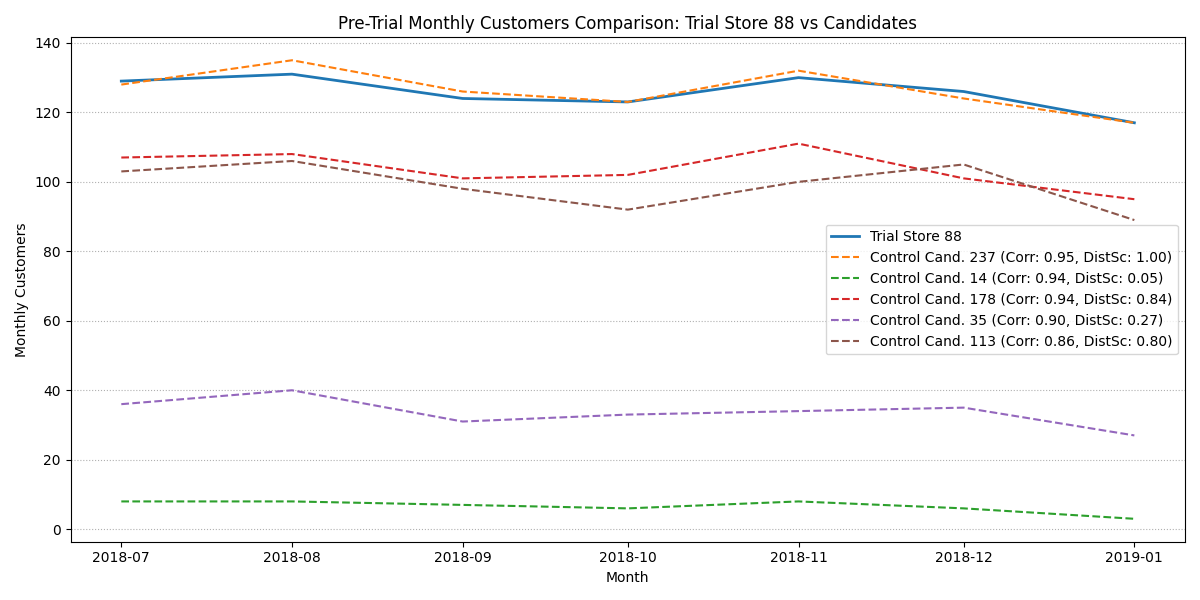

control_selection_store_86_monthly_sales.png


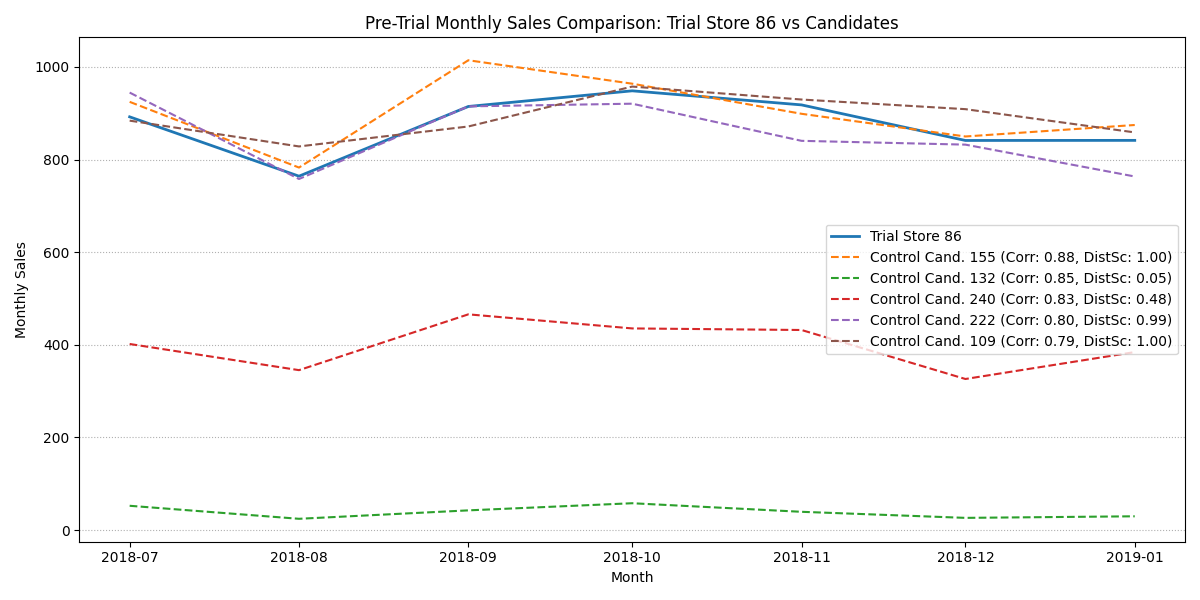

control_selection_store_77_monthly_customers.png


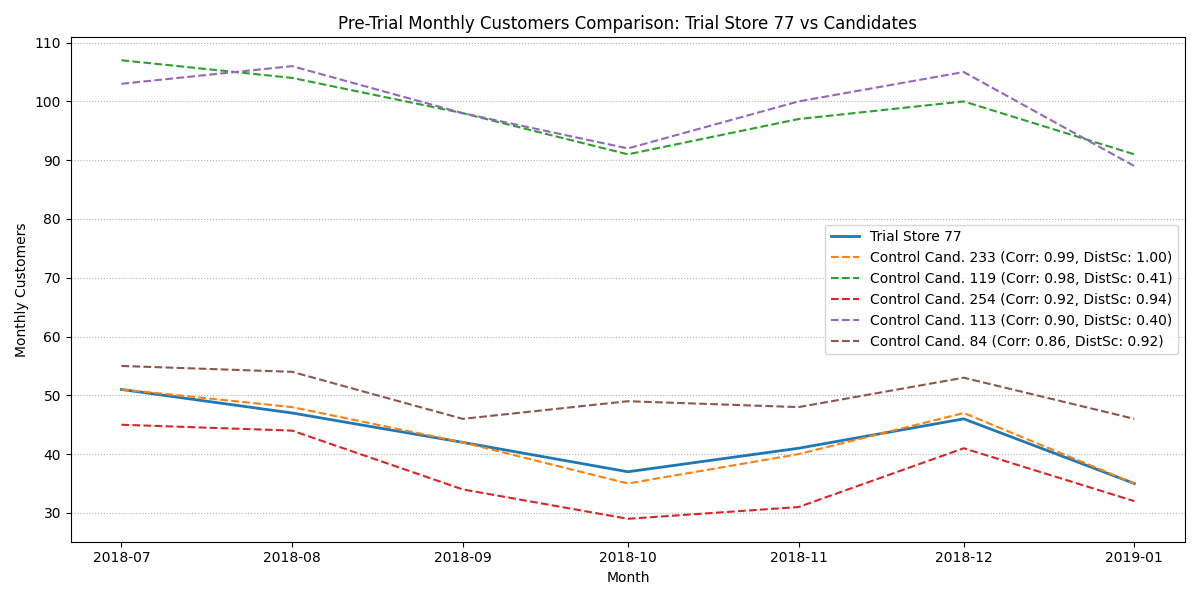

assessment_sales_store_86_vs_155.png


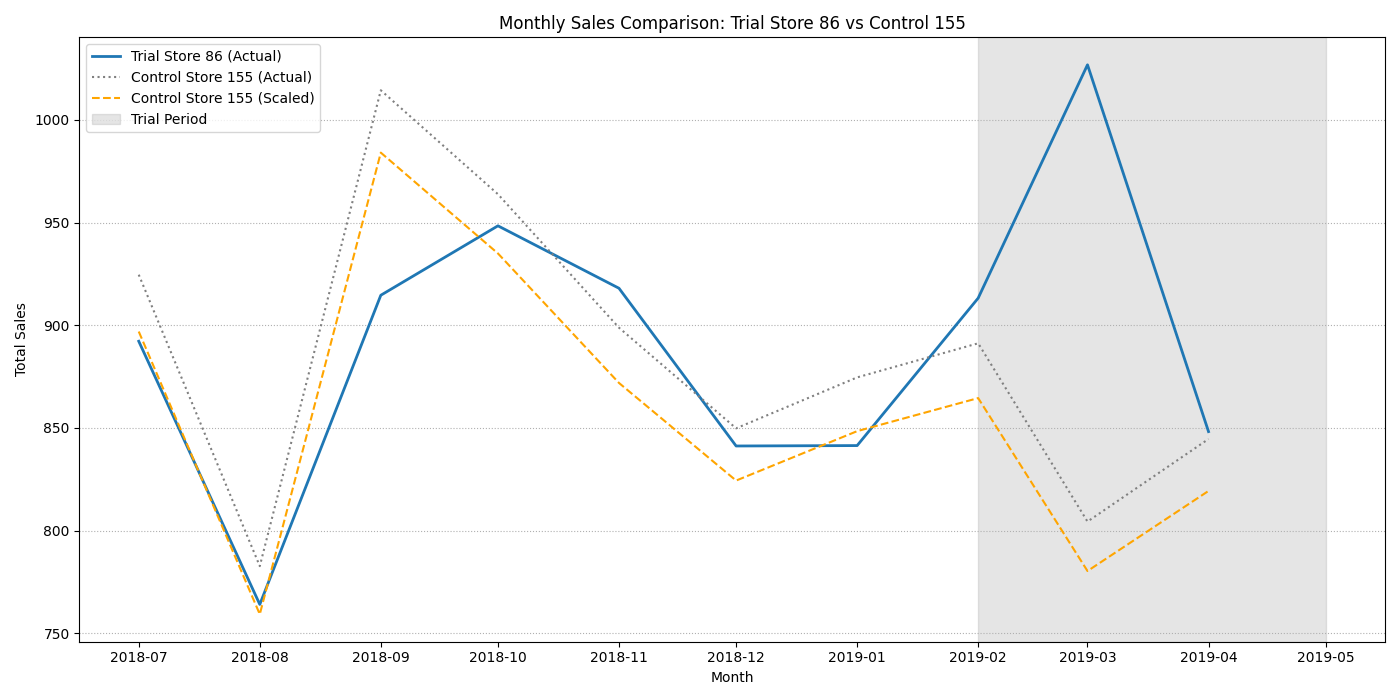

assessment_customers_store_86_vs_155.png


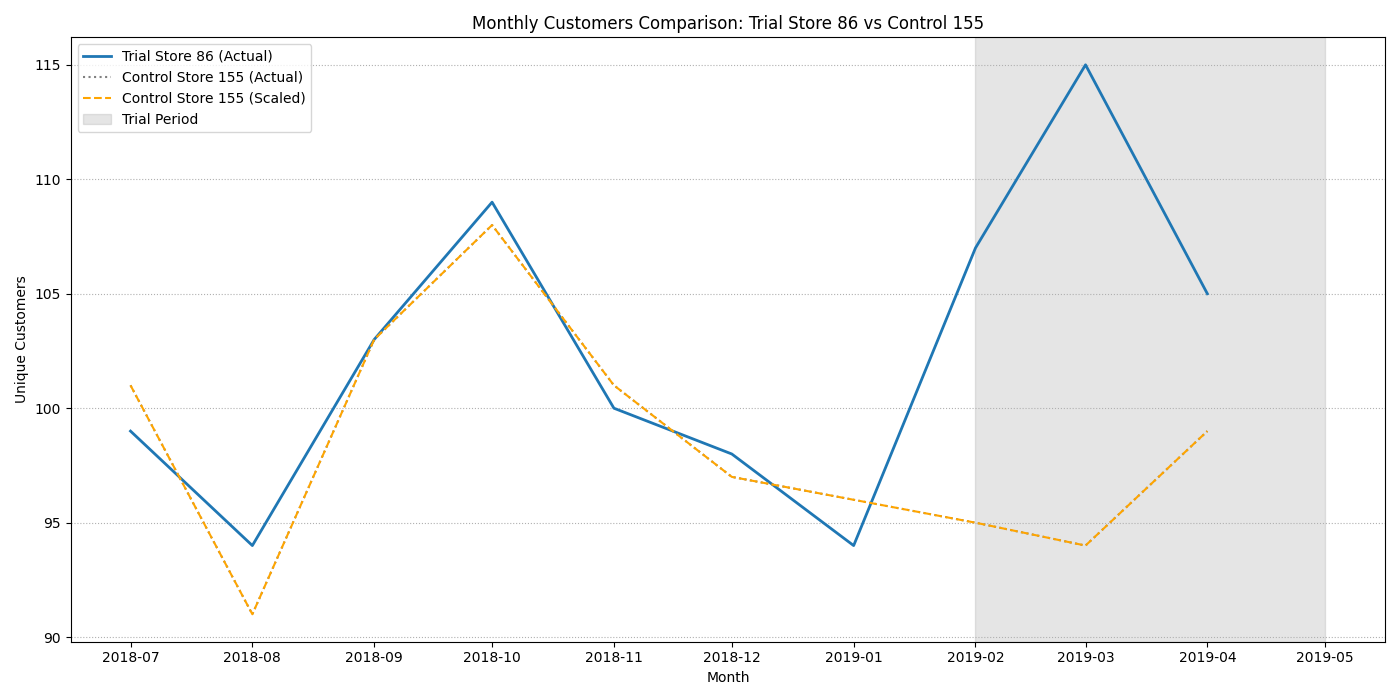

control_selection_store_86_monthly_customers.png


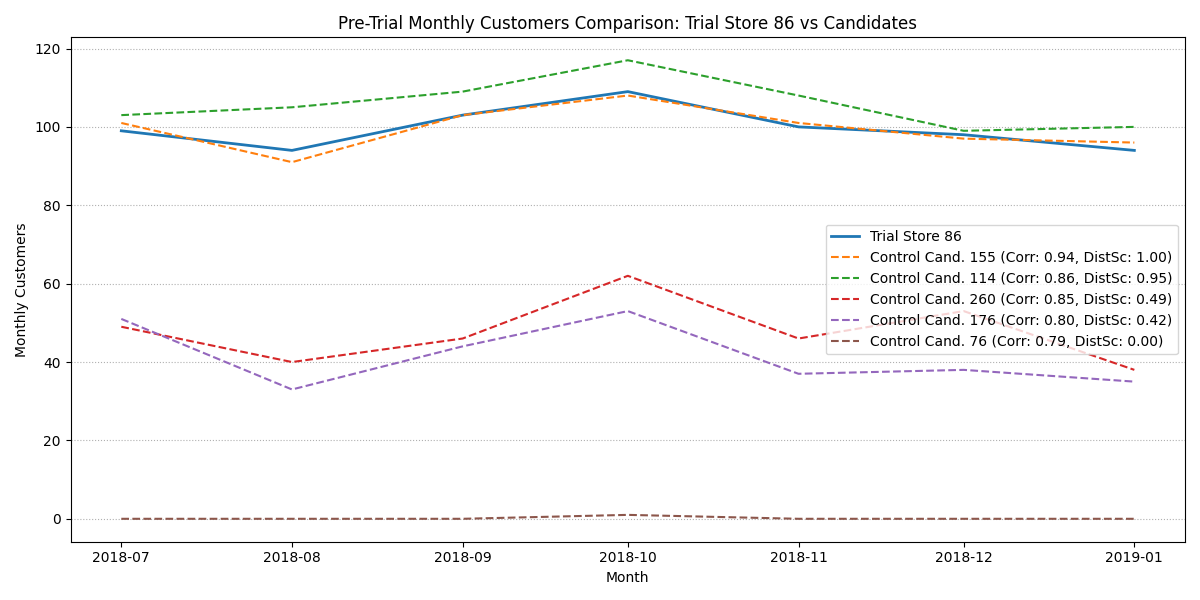

assessment_sales_store_77_vs_71.png


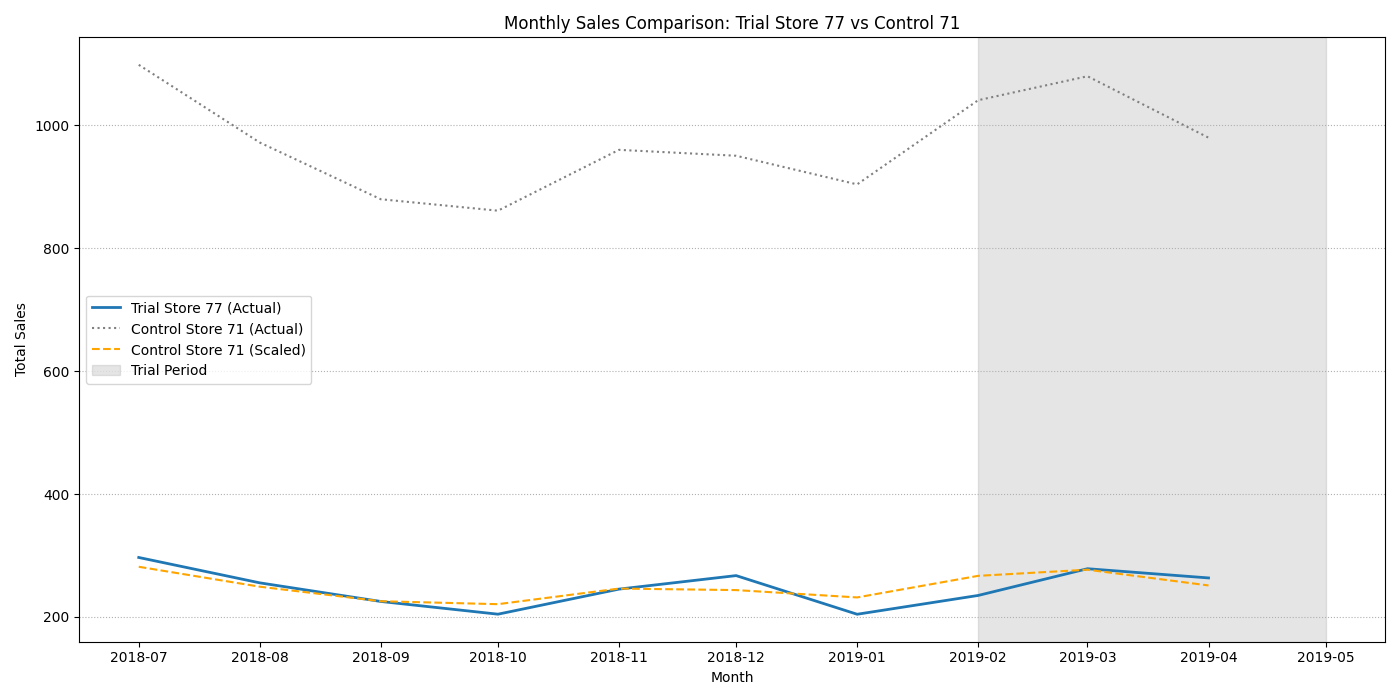

assessment_customers_store_77_vs_71.png


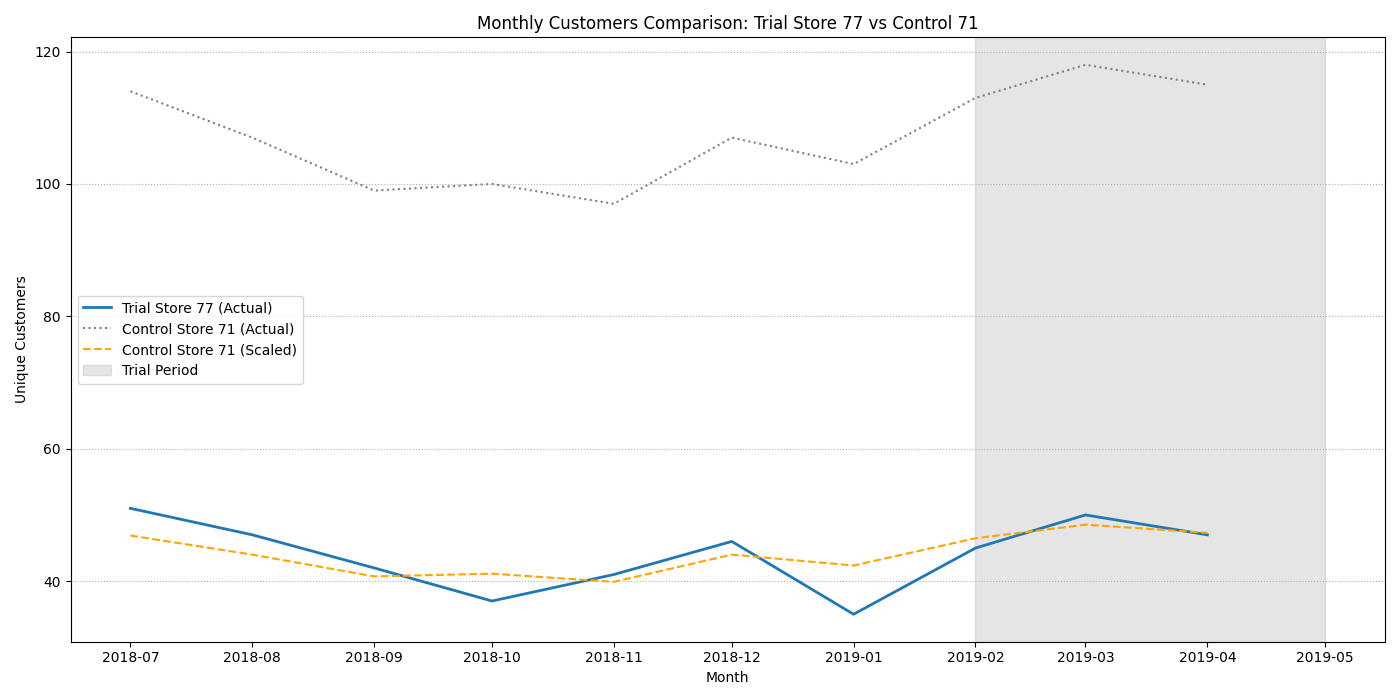

control_selection_store_88_monthly_sales.png


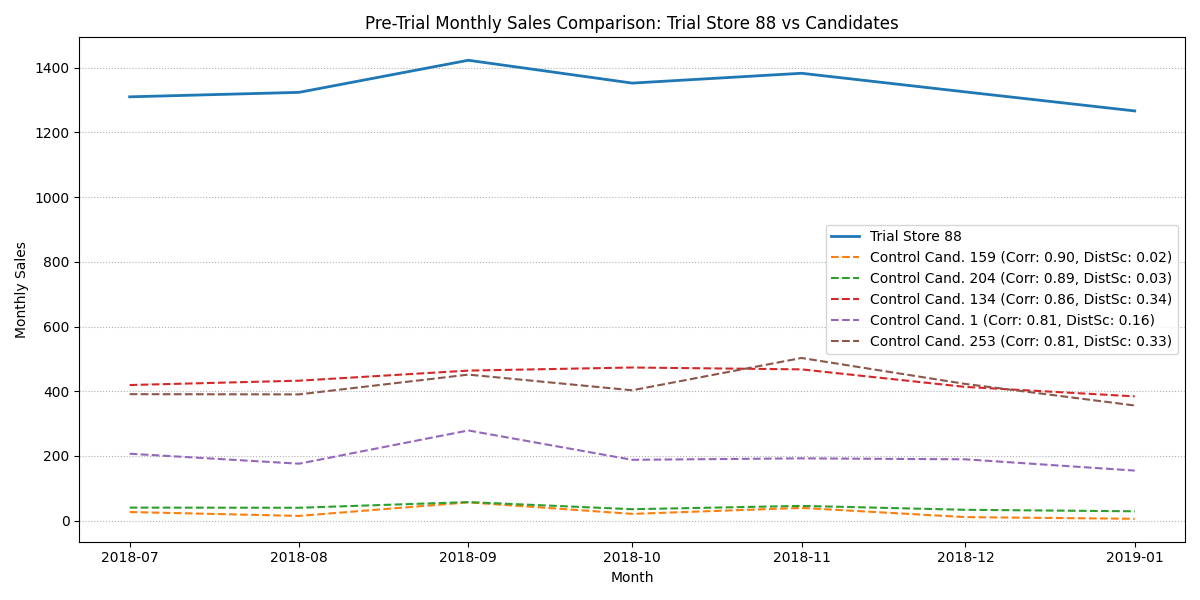

control_selection_store_77_monthly_sales.png


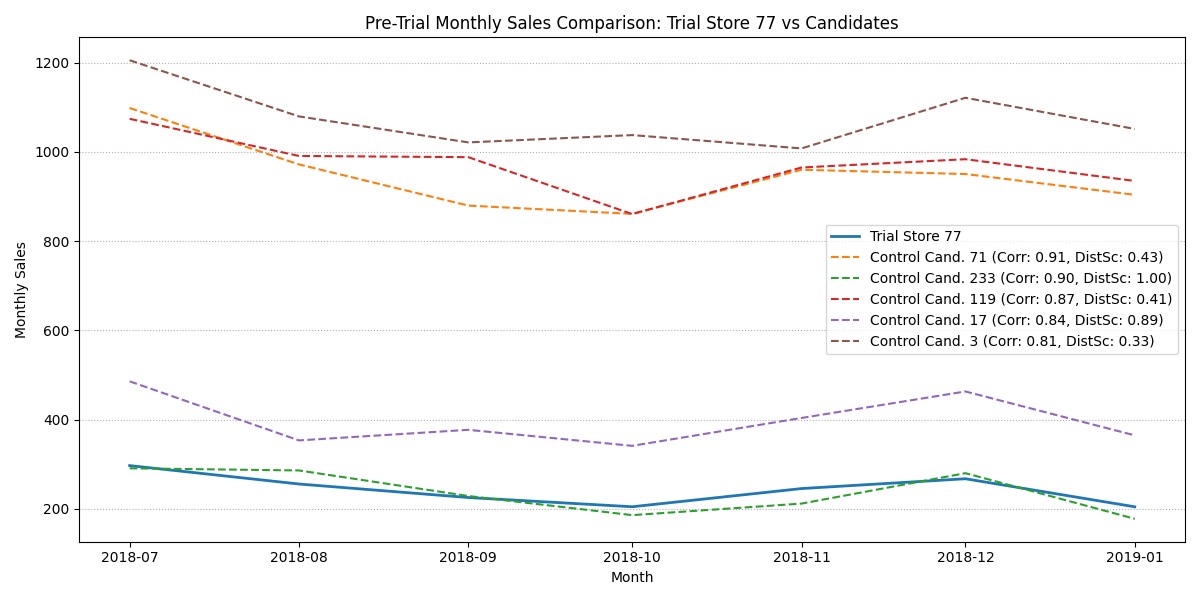

assessment_percent_diff_store_88.png


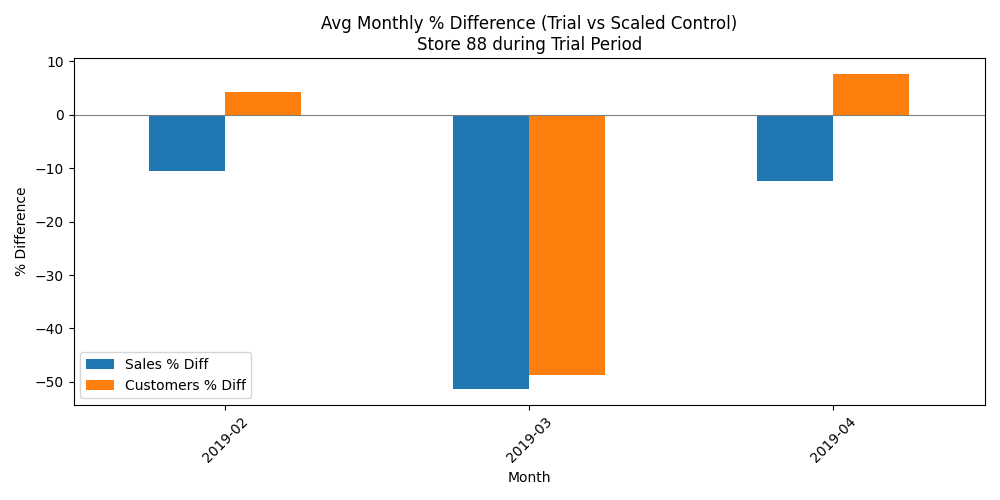

assessment_sales_store_88_vs_159.png


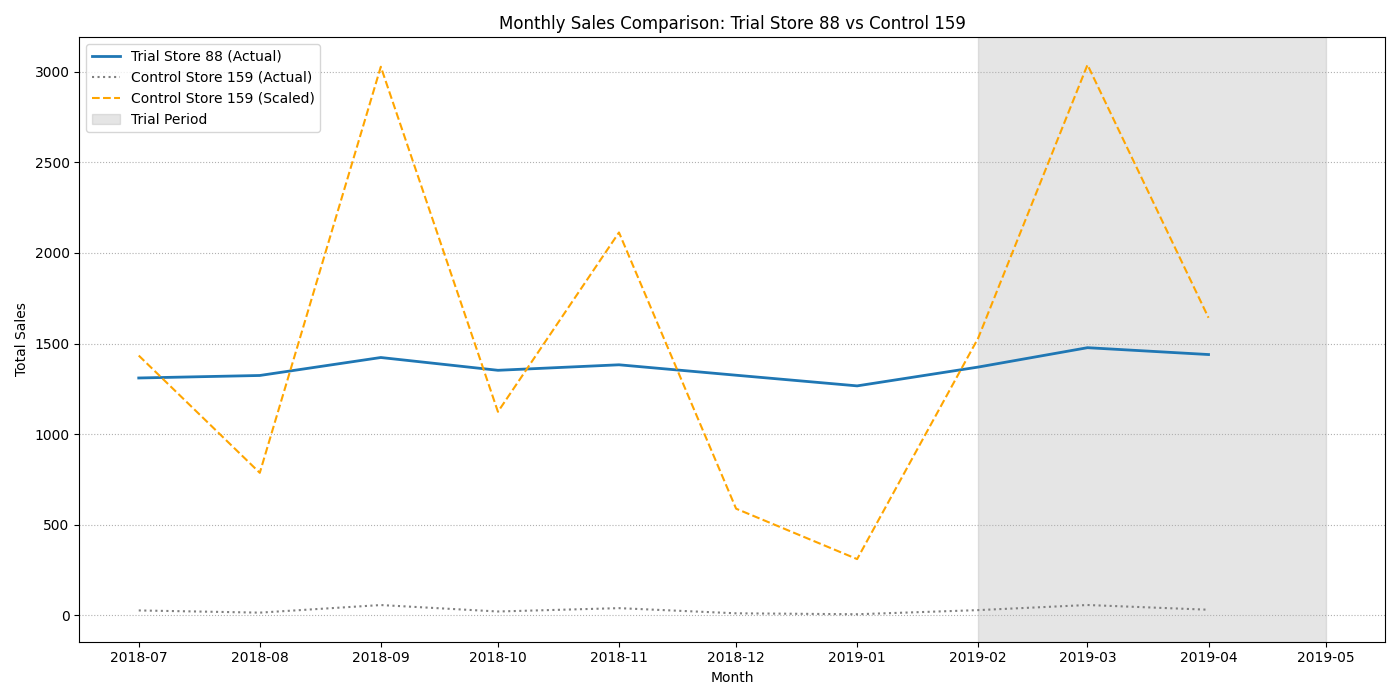

assessment_percent_diff_store_86.png


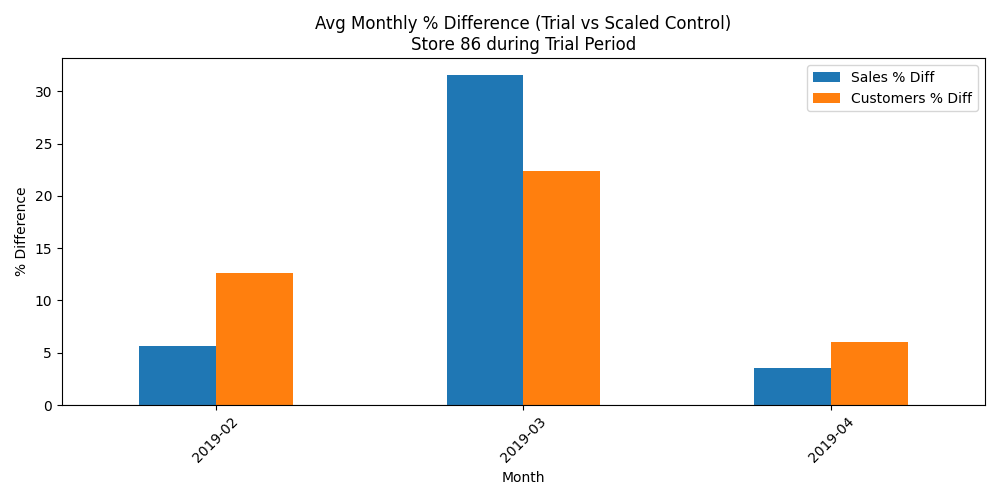

assessment_customers_store_88_vs_159.png


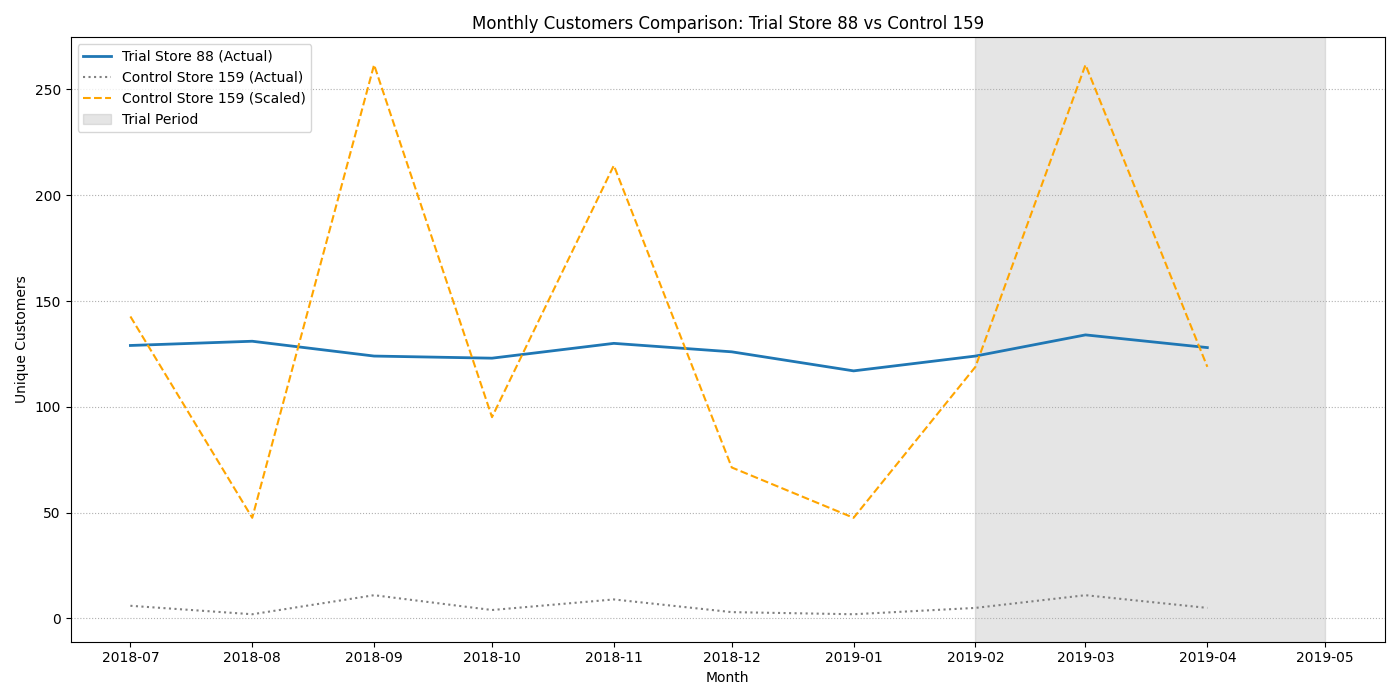

assessment_percent_diff_store_77.png


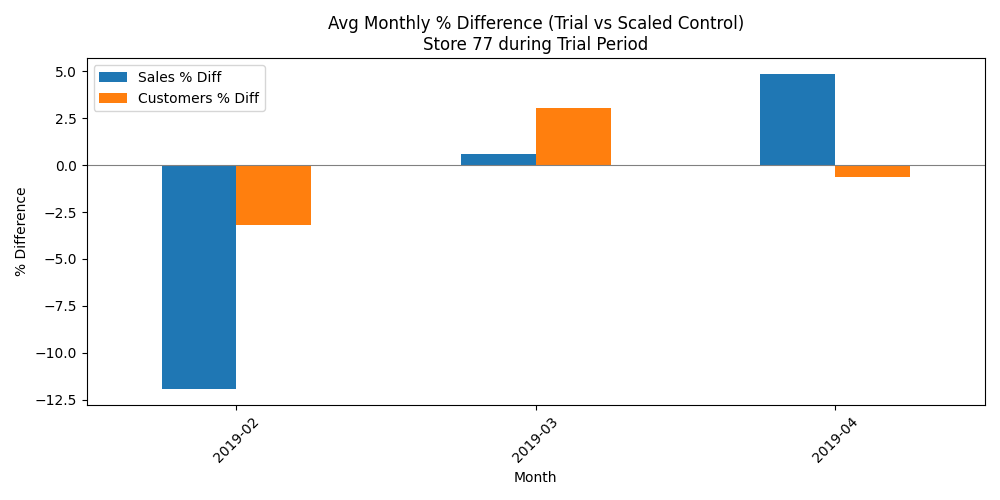

In [65]:
#plot the images of viz dir
for img in os.listdir(OUTPUT_VIS_DIR):
    print(img)
    display(Image(os.path.join(OUTPUT_VIS_DIR, img)))

In [66]:
print("\n--- Findings & Recommendations ---")

# Convert results to DataFrame for easier viewing/reporting
results_df = pd.DataFrame.from_dict(assessment_results, orient='index')
print(results_df)

for trial_store, result in assessment_results.items():
    print(f"\nStore {trial_store}:")
    if 'Control Store' not in result:
         print(f"  - {result['Recommendation']}")
         continue

    control = result['Control Store']
    sales_diff = result['Avg Sales % Diff']
    cust_diff = result['Avg Customer % Diff']
    p_val = result['Significance (Sales P-value)']
    is_sig = result['Significant Sales Change (alpha=0.05)']
    driver = result['Driver Analysis']

    print(f"  - Control Store: {control}")
    print(f"  - Impact on Sales: Average monthly sales during the trial were {sales_diff:.2f}% {'higher' if sales_diff > 0 else 'lower'} than the scaled control store.")
    print(f"  - Statistical Significance: The change in sales was {'statistically significant' if is_sig else 'not statistically significant'} (p={p_val:.4f}).")
    print(f"  - Impact on Customers: Average monthly customer count was {cust_diff:.2f}% {'higher' if cust_diff > 0 else 'lower'} than the scaled control.")
    print(f"  - Driver: {driver}")

    # --- Recommendation ---
    recommendation = f"Recommendation for Store {trial_store}: "
    if is_sig and sales_diff > 0:
        recommendation += "The trial was successful in significantly increasing sales. Consider rolling out the changes."
    elif is_sig and sales_diff < 0:
        recommendation += "The trial resulted in a significant decrease in sales. Do not proceed with the changes; investigate the cause."
    elif not is_sig and sales_diff > 5: # Threshold for potentially meaningful increase
         recommendation += "The trial showed a positive trend in sales, but it was not statistically significant. Consider extending the trial or evaluating qualitative factors before rollout."
    elif not is_sig and sales_diff < -5: # Threshold for potentially meaningful decrease
         recommendation += "The trial showed a negative trend in sales, although not statistically significant. It's advisable not to roll out the changes without further investigation."
    else: # Not significant and small difference
         recommendation += "The trial did not show a significant impact on sales compared to the control store. Rollout is not recommended based on these results."

    print(f"  - {recommendation}")
    # Store recommendation back into the results dictionary/df if needed
    assessment_results[trial_store]['Recommendation'] = recommendation




--- Findings & Recommendations ---
    Control Store  Avg Sales % Diff  Avg Customer % Diff  \
77             71         -2.170083            -0.257987   
86            155         13.580947            13.677537   
88            159        -24.731471           -12.290634   

    Significance (Sales P-value)  Significant Sales Change (alpha=0.05)  \
77                      0.709003                                  False   
86                      0.162843                                  False   
88                      0.316974                                  False   

                                      Driver Analysis  
77                                               None  
86  Indication of change, but not statistically si...  
88  Indication of change, but not statistically si...  

Store 77:
  - Control Store: 71
  - Impact on Sales: Average monthly sales during the trial were -2.17% lower than the scaled control store.
  - Statistical Significance: The change in sales was no

In [68]:

results_df = pd.DataFrame.from_dict(assessment_results, orient='index')
results_df
# results_df.to_csv('trial_assessment_summary.csv')
#print("\nSummary results saved to trial_assessment_summary.csv")

,Control Store,Avg Sales % Diff,Avg Customer % Diff,Significance (Sales P-value),Significant Sales Change (alpha=0.05),Driver Analysis,Recommendation
77,71,-2.170083,-0.257987,0.709003,False,None,Recommendation for Store 77: The trial did not...
86,155,13.580947,13.677537,0.162843,False,"Indication of change, but not statistically si...",Recommendation for Store 86: The trial showed ...
88,159,-24.731471,-12.290634,0.316974,False,"Indication of change, but not statistically si...",Recommendation for Store 88: The trial showed ...
